In [2]:
import os
import sys
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR

import matplotlib.pyplot as plt

torch.manual_seed(8008135)

NOTEBOOK_DIR = Path.cwd()
CODE_DIR = NOTEBOOK_DIR.parent

if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

print("CODE_DIR:", CODE_DIR)
print("CODE_DIR contents:", os.listdir(CODE_DIR))

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"Device set to {device}")

if device.type == "cuda":
    torch.set_float32_matmul_precision("high")

CODE_DIR: /home/daniel/HRM_Reconstruction/code
CODE_DIR contents: ['Utils', 'HRM_Model', 'Datasets', 'BiLSTM_Model', '.GPT2_Model[unused]', 'BERT_Model']
Device set to cuda


In [3]:
from Datasets.Sudoku_DataLoader import get_loaders

from HRM_Model.HRM_Model import HRM
from HRM_Model.HRM_Components import Encoder, HighLevel, LowLevel, Head
from HRM_Model.HRM_Train import train_hrm_deepsup, evaluate_hrm

from Datasets.Sudoku_DataLoader import collect_puzzles_set
from Utils.schedules import cosine_schedule_with_warmup_lr_lambda
from Utils.checkpointing import load_checkpoint
from Utils.visualization import show_sudoku_predictions, print_sudoku_comparison

/home/daniel/anaconda3/envs/HRM/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
train_size = 2**18
test_size = 2**15
batch_size = 2**7

train_dataloader, val_dataloader = get_loaders(
    train_size=train_size,
    test_size=test_size,
    batch_size=batch_size,
)

Map: 100%|██████████| 32768/32768 [00:00<00:00, 41691.45 examples/s]


In [9]:
print("Collecting train puzzles...")
train_puzzles = collect_puzzles_set(train_dataloader)

print("Collecting val puzzles...")
val_puzzles = collect_puzzles_set(val_dataloader)

overlap = train_puzzles.intersection(val_puzzles)

print(f"\nTrain puzzles: {len(train_puzzles)}")
print(f"Val puzzles:   {len(val_puzzles)}")
print(f"Overlap:       {len(overlap)}")

if len(overlap) > 0:
    print("WARNING: Puzzle overlap detected!")
else:
    print("No puzzle overlap between train and validation sets.")


Train puzzles: 262144
Val puzzles:   32768
Overlap:       0
No puzzle overlap between train and validation sets.


In [5]:
# Model hyperparameters
d_model = 512
M = 8 # Max segents
N = 2 # H in segment
T = 2 # L:H ratio
n_layers = 4
n_heads = 8
vocab_size = 10
dropout = 0.2

# Training hyperparameters
lr = 1e-4
min_lr_ratio = 0.1 # -> 1e-5
lr_warmup = 0.05
beta1 = 0.9
beta2 = 0.95
weight_decay = 0.1
num_epochs = 20 # takes ~ 1 day on my 5080

checkpoint_dir = "checkpoints"

In [6]:
high_level = HighLevel(
    d_model=d_model,
    n_layers=n_layers,
    n_heads=n_heads,
    intermediate_size=4 * d_model,
    dropout=dropout,
)

low_level = LowLevel(
    d_model=d_model,
    n_layers=n_layers,
    n_heads=n_heads,
    intermediate_size=4 * d_model,
    dropout=dropout,
)

encoder = Encoder(
    vocab_size=vocab_size,
    d_model=d_model,
)

head = Head(
    d_model=d_model,
    vocab_size=vocab_size,
)

HRM_model = HRM(
    L_module=low_level,
    H_module=high_level,
    encoder=encoder,
    head=head,
    M=M,
    N=N,
    T=T,
    max_len=81,
    d_model=d_model,
).to(device)

print(
    "Number of trainable parameters:",
    f"{sum(p.numel() for p in HRM_model.parameters() if p.requires_grad):,}",
)

Number of trainable parameters: 33,572,864


In [7]:
optimizer = optim.AdamW(
    HRM_model.parameters(),
    lr=lr,
    betas=(beta1, beta2),
    weight_decay=weight_decay,
)

num_training_steps = len(train_dataloader) * num_epochs * M
num_warmup_steps = int(lr_warmup * num_training_steps)

# linear warmup from 0 to 1e-4
# then cosine from 1e-4 to 1e-5
# paper claims to not use that cosine part, but they do on their github
# also we found it empirically works much better
scheduler = LambdaLR(
    optimizer,
    lr_lambda=lambda step: cosine_schedule_with_warmup_lr_lambda(
        step,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps,
        min_ratio=min_lr_ratio
    ),
)

print("num_training_steps:", num_training_steps)
print("num_warmup_steps:", num_warmup_steps)

num_training_steps: 327680
num_warmup_steps: 16384


In [15]:
HRM_model, best_metric, history = train_hrm_deepsup(
    model=HRM_model,
    train_loader=train_dataloader,
    optimizer=optimizer,
    loss_fn=nn.CrossEntropyLoss(ignore_index=-100),
    device=device,
    scheduler=scheduler,
    num_epochs=num_epochs,
    checkpoint_dir=checkpoint_dir,
    checkpoint_every=5, 
    validate_every=5, # better validation on 2^15 examples every 5 epochs
    val_loader=val_dataloader,
    step_val_every=8,
    step_val_batches=1, # 1 batch validation every 8 steps just for logging
)

HRM_model.eval()

print("Best board accuracy used for checkpointing:", best_metric)

Number of trainable parameters: 33,572,864


Epoch 1:   0%|          | 0/2048 [00:01<?, ?it/s]


KeyboardInterrupt: 

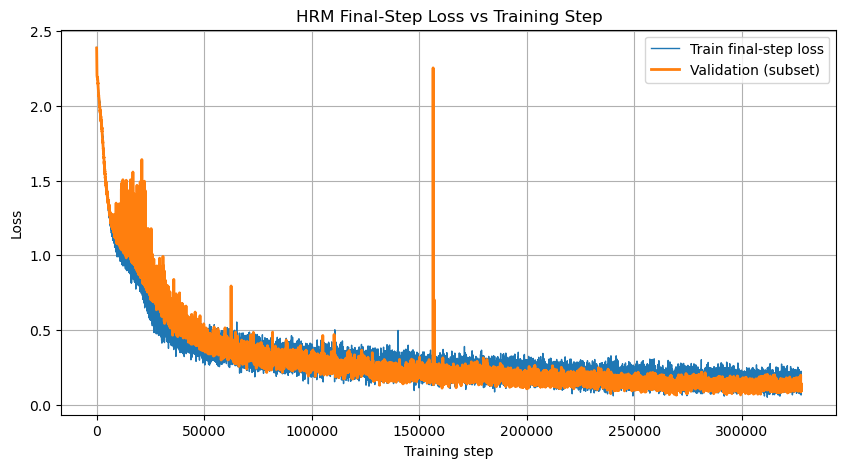

In [ ]:
train_steps = history["step"]
train_loss = history["train_loss"]

val_steps = [
    s for s, v in zip(history["step"], history["val_loss"])
    if v is not None
]

val_loss = [
    v for v in history["val_loss"]
    if v is not None
]

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss, label="Train loss", linewidth=1)

if len(val_loss) > 0:
    plt.plot(
        val_steps,
        val_loss,
        marker="o",
        linestyle="-",
        label="Validation (subset)",
        linewidth=2,
    )

plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("HRM Final-Step Loss vs Training Step")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
HRM_model, _, _, _, _ = load_checkpoint(
    HRM_model,
    optimizer=None,
    scheduler=None,
    path="checkpoints/hrm_best_34M.pt",
    device=device,
)

In [16]:
@torch.no_grad()
def show_hrm_segments(model, val_loader, device, example_idx=0):
    model.eval()

    x_batch, y_batch = next(iter(val_loader))

    x = x_batch[example_idx].to(device).long().unsqueeze(0)
    y = y_batch[example_idx].to(device).long().unsqueeze(0)

    z_H = None
    z_L = None

    print("Input puzzle vs target:")
    print_sudoku_comparison(
        x.squeeze(0).cpu(),
        x.squeeze(0).cpu(),
        y.squeeze(0).cpu(),
    )

    for segment_idx in range(model.M):
        z_H, z_L, logits = model.segment(x, z_H, z_L)

        pred = logits.argmax(dim=-1)
        filled_pred = torch.where(x != 0, x, pred)

        print(f"\nSegment {segment_idx + 1}/{model.M}")
        print_sudoku_comparison(
            x.squeeze(0).cpu(),
            filled_pred.squeeze(0).cpu(),
            y.squeeze(0).cpu(),
        )

        z_H = z_H.detach()
        z_L = z_L.detach()

print("2 segment success example\n")
show_hrm_segments(
    HRM_model,
    val_dataloader,
    device,
    example_idx=0,
)

print("8 segment success example\n")
show_hrm_segments(
    HRM_model,
    val_dataloader,
    device,
    example_idx=2,
)

print("Failure example\n")
show_hrm_segments(
    HRM_model,
    val_dataloader,
    device,
    example_idx=4,
)

2 segment success example

Input puzzle vs target:
Input / Prediction
0 9 0 | 0 0 1 | 2 0 0 
0 3 0 | 0 2 8 | 4 0 6 
0 6 0 | 0 0 0 | 0 8 0 
---------------------------------
0 7 0 | 0 0 0 | 1 4 0 
0 2 0 | 0 5 0 | 7 0 0 
0 0 3 | 0 0 0 | 0 0 2 
---------------------------------
0 1 0 | 9 0 0 | 0 0 0 
0 0 0 | 7 0 5 | 0 0 0 
0 8 7 | 2 0 6 | 0 0 4 


Segment 1/8
Input / Prediction
8 9 4 | 6 3 1 | 2 7 3 
7 3 1 | 5 2 8 | 4 9 6 
2 6 5 | 4 9 7 | 3 8 1 
---------------------------------
9 7 9 | 3 6 2 | 1 4 5 
1 2 6 | 1 5 4 | 7 3 9 
4 5 3 | 1 7 9 | 8 6 2 
---------------------------------
2 1 5 | 9 4 3 | 6 7 7 
3 4 2 | 7 8 5 | 6 1 9 
9 8 7 | 2 1 6 | 9 5 4 


Segment 2/8
Input / Prediction
5 9 8 | 4 6 1 | 2 7 3 
7 3 1 | 5 2 8 | 4 9 6 
2 6 4 | 3 9 7 | 5 8 1 
---------------------------------
8 7 9 | 6 3 2 | 1 4 5 
4 2 6 | 1 5 9 | 7 3 8 
1 5 3 | 8 7 4 | 9 6 2 
---------------------------------
6 1 5 | 9 4 3 | 8 2 7 
3 4 2 | 7 8 5 | 6 1 9 
9 8 7 | 2 1 6 | 3 5 4 


Segment 3/8
Input / Prediction
5 9 8 

In [10]:
old_M, old_N, old_T = HRM_model.M, HRM_model.N, HRM_model.T

for M in [4, 8, 16]:
    for N in [1, 2, 4]:
        for T in [2, 4, 8]:
            HRM_model.M = M
            HRM_model.N = N
            HRM_model.T = T
            HRM_model.eval()

            val_loss, token_acc, board_acc = evaluate_hrm(
                HRM_model,
                val_dataloader,
                nn.CrossEntropyLoss(ignore_index=-100),
                device,
            )

            print(
                f"M={M}, N={N}, T={T} | "
                f"Loss={val_loss:.4f}, "
                f"Token={token_acc:.4f}, "
                f"Board={board_acc:.4f}"
            )

HRM_model.M, HRM_model.N, HRM_model.T = old_M, old_N, old_T

Validation: 100%|██████████| 256/256 [00:52<00:00,  4.86it/s]


M=4, N=1, T=2 | Loss=0.4637, Token=0.8009, Board=0.5385


Validation: 100%|██████████| 256/256 [01:26<00:00,  2.95it/s]


M=4, N=1, T=4 | Loss=0.3863, Token=0.8381, Board=0.6712


Validation: 100%|██████████| 256/256 [02:31<00:00,  1.68it/s]


...

M=16, N=4, T=2 | Loss=0.0777, Token=0.9674, Board=0.9390


Validation: 100%|██████████| 256/256 [22:06<00:00,  5.18s/it]


M=16, N=4, T=4 | Loss=0.0730, Token=0.9717, Board=0.9449


Validation: 100%|██████████| 256/256 [39:47<00:00,  9.33s/it]

M=16, N=4, T=8 | Loss=0.0759, Token=0.9741, Board=0.9475
